In [ ]:
from dowhy import CausalModel
from graphviz import Digraph
import matplotlib.pyplot as plt
import pandas as pd
from pgmpy.estimators.CITests import chi_square
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.tree import DecisionTreeClassifier

### Load dataset + examine

In [26]:
df = pd.read_csv('../data/software_usage_promotion.csv')

#df['Combined Treatment'] = (df['Discount'] + 2*df['Tech Support']).astype('category')
df['Combined Treatment'] = (df['Discount'] + df['Tech Support']).astype('category')
# df['Discount'] = df['Discount'].astype('int')
# df['Tech Support'] = df['Discount'].astype('int')

In [31]:
df

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,Combined Treatment
0,1,0,1,0,45537,26,26,152205,0,1,17688.363000,1
1,0,0,1,1,20842,107,70,159038,0,1,14981.435590,1
2,0,0,0,1,82171,10,7,264935,1,1,32917.138940,2
3,0,0,0,0,30288,40,39,77522,1,1,14773.768550,2
4,0,0,1,0,25930,37,43,91446,1,1,17098.698230,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,1,1,46186,74,48,141579,0,1,13930.128620,1
1996,0,0,1,0,39683,12,13,111848,0,0,4753.072214,0
1997,0,1,0,0,4195,14,17,11924,0,0,2161.745939,0
1998,1,0,0,1,10664,68,47,40037,1,1,17694.820790,2


In [8]:
df['Combined Treatment'].unique()

[1, 3, 2, 0]
Categories (4, int64): [0, 1, 2, 3]

In [59]:
df.describe()

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.202000,0.1950,0.504500,0.691000,28272.703000,61.115000,57.345500,113159.120000,0.503000,0.510500,15397.917422
std,0.401593,0.3963,0.500105,0.462197,28207.138885,53.449707,52.861123,100987.600092,0.500116,0.500015,11290.944451
min,0.000000,0.0000,0.000000,0.000000,1161.000000,10.000000,6.000000,10101.000000,0.000000,0.000000,-616.572451
25%,0.000000,0.0000,0.000000,0.000000,8914.000000,24.000000,22.000000,39282.000000,0.000000,0.000000,7545.052008
50%,0.000000,0.0000,1.000000,1.000000,19210.500000,44.000000,41.000000,81378.000000,1.000000,1.000000,12582.446440
75%,0.000000,0.0000,1.000000,1.000000,37991.500000,79.000000,74.000000,155635.000000,1.000000,1.000000,19662.979475
max,1.000000,1.0000,1.000000,1.000000,259808.000000,535.000000,407.000000,766485.000000,1.000000,1.000000,86006.924450


### Create DAG

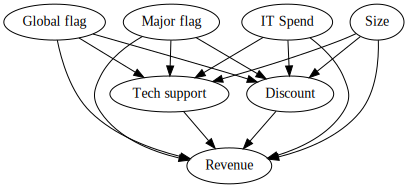

In [9]:
dot = Digraph(comment='Software Sales Causal DAG')

dot.node('G', 'Global flag')
dot.node('M', 'Major flag')
dot.node('IT', 'IT Spend')
dot.node('S', 'Size')
dot.node('T', 'Tech support')
dot.node('R', 'Revenue')
dot.node('D', 'Discount')

dot.edges([
    ('S', 'D'),
    ('S', 'R'),
    ('S', 'T'),
    ('IT', 'D'),
    ('IT', 'R'),
    ('IT', 'T'),
    ('G', 'D'),
    ('G', 'R'),
    ('G', 'T'),
    ('M', 'D'),
    ('M', 'R'),
    ('M', 'T'),
    ('D', 'R'),
    ('T', 'R')])

dot

Client company attributes cause both decisions to offer tech support and discount as well as revenue

### Sense-Check

In [10]:
#### Verify that company parameters & revenue aren't independent given tech support / discount

In [11]:
# convert revenue to bins
df['Revenue Binned'] = pd.cut(df.Revenue, 5)

In [12]:
significance = 0.05
chi_square(X="Revenue Binned",
           Y="Global Flag",
           Z=["Discount", "Tech Support"],
           data=df,
           boolean=False,
           significance_level=significance)


In [13]:
significance = 0.05
chi_square(X="Revenue Binned",
           Y="Global Flag",
           Z=[],
           data=df,
           boolean=False,
           significance_level=significance)

As we would expect, revenue and global flag aren't independent.
They're also not conditionally independent given Discount and tech support.

### Build doWhy model

In [21]:
confounders = [
    'Size', 'Employee Count', 'PC Count', 'IT Spend', 'Major Flag',
    'Global Flag', 'Commercial Flag', 'SMC Flag'
]

model = CausalModel(
    data=df.drop(columns=['Combined Treatment', 'Revenue Binned']),
    treatment=['Discount'],
    outcome='Revenue',
    common_causes=
    confounders
)

identified_estimand = model.identify_effect()

INFO:dowhy.causal_model:Model to find the causal effect of treatment ['Discount'] on outcome ['Revenue']
INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.
INFO:dowhy.causal_identifier.auto_identifier:Instrumental variables for treatment and outcome:[]
INFO:dowhy.causal_identifier.auto_identifier:Frontdoor variables for treatment and outcome:[]
INFO:dowhy.causal_identifier.auto_identifier:Number of general adjustment sets found: 1
INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.


In [22]:
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[Revenue|Global Flag,SMC Flag,Size,Commercial Flag,IT Spend,PC Co ↪
d[Discount]                                                                    ↪

↪                                
↪ unt,Employee Count,Major Flag])
↪                                
Estimand assumption 1, Unconfoundedness: If U→{Discount} and U→Revenue then P(Revenue|Discount,Global Flag,SMC Flag,Size,Commercial Flag,IT Spend,PC Count,Employee Count,Major Flag,U) = P(Revenue|Discount,Global Flag,SMC Flag,Size,Commercial Flag,IT Spend,PC Count,Employee Count,Major Flag)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                         

In [63]:
tree_model = DecisionTreeClassifier(max_depth=3)

In [27]:
df

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,Combined Treatment
0,1,0,1,0,45537,26,26,152205,0,1,17688.363000,1
1,0,0,1,1,20842,107,70,159038,0,1,14981.435590,1
2,0,0,0,1,82171,10,7,264935,1,1,32917.138940,2
3,0,0,0,0,30288,40,39,77522,1,1,14773.768550,2
4,0,0,1,0,25930,37,43,91446,1,1,17098.698230,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,1,1,46186,74,48,141579,0,1,13930.128620,1
1996,0,0,1,0,39683,12,13,111848,0,0,4753.072214,0
1997,0,1,0,0,4195,14,17,11924,0,0,2161.745939,0
1998,1,0,0,1,10664,68,47,40037,1,1,17694.820790,2


In [ ]:
causal_estimate_tree = model.estimate_effect(
    identified_estimand=identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    target_units = lambda df: df['Global Flag']==1,
    method_params=  {'init_params': {'model_y': GradientBoostingRegressor(),
                                   'model_t': tree_model,
                                   'discrete_treatment': True},
                    'fit_params': {}
                    }
                        )

INFO:dowhy.causal_estimator:INFO: Using EconML Estimator
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 


In [65]:
print(causal_estimate_tree)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[Revenue|Global Flag,SMC Flag,Size,Commercial Flag,IT Spend,PC Co ↪
d[Discount]                                                                    ↪

↪                                
↪ unt,Employee Count,Major Flag])
↪                                
Estimand assumption 1, Unconfoundedness: If U→{Discount} and U→Revenue then P(Revenue|Discount,Global Flag,SMC Flag,Size,Commercial Flag,IT Spend,PC Count,Employee Count,Major Flag,U) = P(Revenue|Discount,Global Flag,SMC Flag,Size,Commercial Flag,IT Spend,PC Count,Employee Count,Major Flag)

## Realized estimand
b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
Target units: Data subset defined by a function

## Estimate
Mean value: 4

### Refutation Tests

In [66]:
data_red = model.refute_estimate(
    identified_estimand,
    causal_estimate_tree,
    method_name='data_subset_refuter',
    subset_fraction=0.8,
    num_simulations=100
)

INFO:dowhy.causal_refuters.data_subset_refuter:Refutation over 0.8 simulated datasets of size 1600.0 each
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Siz

In [67]:
print(data_red)

Refute: Use a subset of data
Estimated effect:4976.301184910873
New effect:5013.422579531322
p value:0.76



In [68]:
dummy_conf = model.refute_estimate(
    identified_estimand,
    causal_estimate_tree,
    method_name='random_common_cause',
    num_simulations=100
)

INFO:dowhy.causal_refuters.random_common_cause:Refutation over 100 simulated datasets, each with a random common cause added
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag+w_random | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag+w_random | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag+w_random | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag+w_random | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag+w_random | 
INFO:dowhy.causal_estimator:b: Revenue~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag+w_random | 

In [72]:
print(dummy_conf)

Refute: Use a Placebo Treatment
Estimated effect:4976.301184910873
New effect:-34.311596117680885
p value:0.92



In [73]:
dummy_treatment = model.refute_estimate(
    identified_estimand,
    causal_estimate_tree,
    method_name='placebo_treatment_refuter',
    num_simulations=100
)

INFO:dowhy.causal_refuters.placebo_treatment_refuter:Refutation over 100 simulated datasets of PlaceboType.DEFAULT treatment
INFO:dowhy.causal_refuters.placebo_treatment_refuter:Using a Discrete Uniform Distribution lying between 0 and 1
INFO:dowhy.causal_estimator:b: Revenue~placebo+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_refuters.placebo_treatment_refuter:Using a Discrete Uniform Distribution lying between 0 and 1
INFO:dowhy.causal_estimator:b: Revenue~placebo+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_refuters.placebo_treatment_refuter:Using a Discrete Uniform Distribution lying between 0 and 1
INFO:dowhy.causal_estimator:b: Revenue~placebo+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_refuters.placebo_treatment_refuter:Using a Discrete Uniform Distribution lying between 0 and 1
INFO:dowhy.caus

In [74]:
print(dummy_treatment)

Refute: Use a Placebo Treatment
Estimated effect:4976.301184910873
New effect:30.823492731716016
p value:0.8600000000000001



In [75]:
dummy_outcome = model.refute_estimate(
    identified_estimand,
    causal_estimate_tree,
    method_name='dummy_outcome_refuter',
    num_simulations=100
)

INFO:dowhy.causal_refuters.dummy_outcome_refuter:Refutation over 100 simulated datasets
INFO:dowhy.causal_refuters.dummy_outcome_refuter:The transformation passed: [('zero', ''), ('noise', {'std_dev': 1})]
INFO:dowhy.causal_refuter:All variables required: Running bootstrap adding noise to confounders, instrumental variables and effect modifiers.
INFO:dowhy.causal_estimator:b: dummy_outcome~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: dummy_outcome~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: dummy_outcome~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: dummy_outcome~Discount+Global Flag+SMC Flag+Size+Commercial Flag+IT Spend+PC Count+Employee Count+Major Flag | 
INFO:dowhy.causal_estimator:b: dummy_outcome~Discount+Global Flag+SMC Flag+Size+

In [76]:
print(dummy_outcome[0])

Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.0020399112967060228
p value:0.84



The 4 refutation tests - decreasing data size, adding dummy confounder, adding
dummy treatment and dummy outcome all did not refute the current modeling.

It must be noted that initially, when the max_depth was set to 5 for the
decision tree, the dummy confounder test failed, suggesting overfitting.

To check this, we a build decision tree treatment model (in the parlance
of DML) with max depth 3 and 5 with cross-validation.

In [104]:
y = df['Discount'].values
X = df[confounders].values

tree_complex = DecisionTreeClassifier(max_depth=5)
propensities_complex = cross_val_predict(tree_complex, X, y, cv=5, method='predict_proba')[:,1]

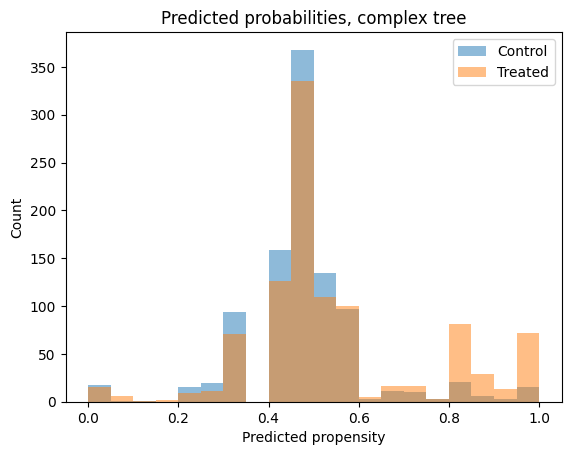

In [107]:
plt.hist(propensities_complex[y==0], bins=20, alpha=0.5, label='Control')
plt.hist(propensities_complex[y==1], bins=20, alpha=0.5, label='Treated')
plt.xlabel('Predicted propensity')
plt.title('Predicted probabilities, complex tree')
plt.ylabel('Count')
plt.legend()
plt.show()

In [108]:
tree_simple = DecisionTreeClassifier(max_depth=3)
propensities_simple = cross_val_predict(tree_simple, X, y, cv=5, method='predict_proba')[:,1]

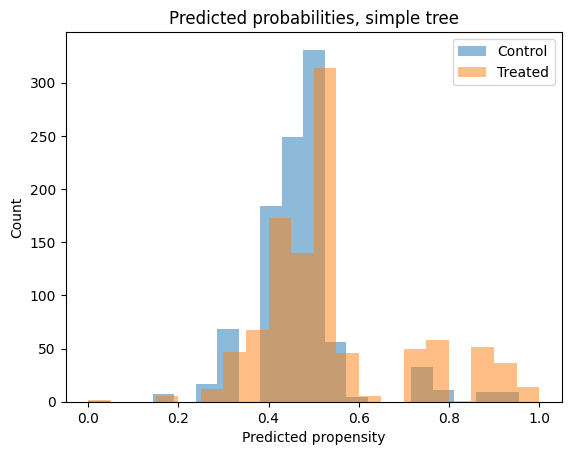

In [110]:
plt.hist(propensities_simple[y==0], bins=20, alpha=0.5, label='Control')
plt.hist(propensities_simple[y==1], bins=20, alpha=0.5, label='Treated')
plt.xlabel('Predicted propensity')
plt.ylabel('Count')
plt.title('Predicted probabilities, simple tree')
plt.legend()
plt.show()

> **Conclusion:** We see better separation with the simpler trees.  This supports hypothesis
that treatment model with a max depth of 5 was otherwise overfit.

### Next Steps

This initial exploration shows that refutation tests pass.
However, in this dataset, we have 2 treatments.
So we actually need to perform this exercise 2 more times:  
* Tech support model  
* Discount + tech support model

It is better to functionalize this

### Modeling Thoughts

While DML has the benefit of modeling confounders expicitly, its drawback is that it doesn't provide individual CATEs. 
As a result, after performing refutation tests, we will model using Causal Forests.  This will allow us to then provide  
recommendations about counterfactual treatments, and estimate the associated expected effect on revenue. 